# Feature Engineering, Clustering y Experimentos A/B

## Configuración

In [1]:
import warnings, os, json, itertools, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve, silhouette_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

MODEL_COLORS = {
    'KNN': 'blue', 'Reg. Logística': 'orange', 'SVM (RBF)': 'teal', 'MLP': 'magenta',
    'Árbol de Decisión': 'green', 'Random Forest': 'darkred', 'ExtraTrees': 'olive',
    'HistGradientBoosting': 'brown', 'XGBoost': 'purple', 'LightGBM': 'darkcyan', 'CatBoost': 'goldenrod',
}
MODELOS = list(MODEL_COLORS.keys())

df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES_BASE = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

with open('outputs_sprint1/resumen_sprint1.json') as f:
    RESUMEN_S1 = json.load(f)
F1_SPRINT1 = RESUMEN_S1['f1_final']
MEJOR_BAL_S1 = RESUMEN_S1['metodo_balanceo']
BAL_POR_MOD = RESUMEN_S1['balanceo_por_modelo']

os.makedirs('outputs_sprint2', exist_ok=True)
print(f'Modelos: {len(MODELOS)} | Features base: {len(FEATURES_BASE)}')
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'F1_CV ganador Sprint 1: {F1_SPRINT1:.4f} ({RESUMEN_S1["mejor_modelo"]}, {MEJOR_BAL_S1})')

Modelos: 11 | Features base: 46
Train: (1705, 46) | Test: (427, 46)
F1_CV ganador Sprint 1: 0.7277 (CatBoost, RandomOverSampler)


## Funciones

In [2]:
def crear_clf(mod):
    if mod == 'KNN':                  return KNeighborsClassifier(n_neighbors=5)
    if mod == 'Reg. Logística':       return LogisticRegression(max_iter=1000, random_state=SEED)
    if mod == 'SVM (RBF)':            return SVC(kernel='rbf', probability=True, random_state=SEED)
    if mod == 'MLP':                  return MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=SEED)
    if mod == 'Árbol de Decisión':    return DecisionTreeClassifier(random_state=SEED)
    if mod == 'Random Forest':        return RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    if mod == 'ExtraTrees':           return ExtraTreesClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    if mod == 'HistGradientBoosting': return HistGradientBoostingClassifier(random_state=SEED)
    if mod == 'XGBoost':              return xgb.XGBClassifier(n_estimators=100, random_state=SEED,
                                                               eval_metric='logloss', tree_method='hist', n_jobs=-1)
    if mod == 'LightGBM':             return lgb.LGBMClassifier(n_estimators=100, random_state=SEED, verbose=-1, n_jobs=-1)
    if mod == 'CatBoost':             return CatBoostClassifier(iterations=100, random_seed=SEED,
                                                               verbose=0, allow_writing_files=False)
    raise ValueError(mod)

def crear_balanceador(nombre):
    if nombre == 'Sin balanceo':      return None
    if nombre == 'RandomOverSampler': return RandomOverSampler(random_state=SEED)
    if nombre == 'SMOTE':             return SMOTE(random_state=SEED, k_neighbors=5)
    if nombre == 'BorderlineSMOTE':   return BorderlineSMOTE(random_state=SEED, k_neighbors=5)
    if nombre == 'ADASYN':            return ADASYN(random_state=SEED)
    if nombre == 'SMOTETomek':        return SMOTETomek(random_state=SEED)
    raise ValueError(nombre)

def construir_pipeline(mod, balanceo='Sin balanceo'):
    pasos = [('sc', StandardScaler())]
    bal = crear_balanceador(balanceo)
    if bal is not None:
        pasos.append(('bal', bal))
    pasos.append(('clf', crear_clf(mod)))
    return ImbPipeline(pasos)

def f1_cv(mod, Xtr, ytr, balanceo='Sin balanceo'):
    '''MÉTRICA PRIMARIA: F1 clase positiva por CV 5-fold. Devuelve (media, std).'''
    pipe = construir_pipeline(mod, balanceo)
    sc = cross_val_score(pipe, Xtr, ytr, cv=CV5, scoring='f1', n_jobs=-1)
    return sc.mean(), sc.std()

def scores_pos(pipe, Xte):
    clf = pipe.named_steps['clf']
    if hasattr(clf, 'predict_proba'):
        return pipe.predict_proba(Xte)[:, 1]
    return pipe.decision_function(Xte)

def metricas_holdout(yte, y_pred, y_sco):
    return {
        'F1': f1_score(yte, y_pred), 'Accuracy': accuracy_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred, zero_division=0), 'Recall': recall_score(yte, y_pred),
        'AUC-ROC': roc_auc_score(yte, y_sco), 'AUC-PR': average_precision_score(yte, y_sco),
    }

def resaltar_maximo(s):
    estilos = [''] * len(s)
    estilos[s.index.get_loc(s.idxmax())] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Funciones listas')

Funciones listas


## Selección de elementos no económicos

In [3]:
ECONOMICOS = ['Au_ppm', 'Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm']
UMBRAL_CENS = 0.30

df_raw = pd.read_csv('../data/raw/DataSet.csv')
def frac_censurado(col):
    if col not in df_raw.columns:
        return 0.0
    s = df_raw[col].astype(str).str.strip()
    return float(s.str.startswith(('<', '>')).mean())

no_econ_all = [c for c in FEATURES_BASE if c not in ECONOMICOS]
cens = {c: round(frac_censurado(c), 3) for c in no_econ_all}
NO_ECON = [c for c in no_econ_all if cens[c] <= UMBRAL_CENS]
descartados = [c for c in no_econ_all if cens[c] > UMBRAL_CENS]

print(f'Económicos excluidos ({len(ECONOMICOS)}): {ECONOMICOS}')
print(f'No económicos totales: {len(no_econ_all)}')
print(f'Descartados por censura >{int(UMBRAL_CENS*100)}% ({len(descartados)}): '
      f'{ {c: cens[c] for c in descartados} }')
print(f'No económicos válidos para FE: {len(NO_ECON)}')

pd.Series(cens).sort_values(ascending=False).to_csv('outputs_sprint2/censura_no_economicos.csv',
                                                     header=['frac_censurado'])
print(NO_ECON)

Económicos excluidos (5): ['Au_ppm', 'Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm']
No económicos totales: 42
Descartados por censura >30% (3): {'Re_ppm': 0.947, 'Se_ppm': 0.818, 'Te_ppm': 0.682}
No económicos válidos para FE: 39
['Al_per', 'As_ppm', 'Ba_ppm', 'Be_ppm', 'Bi_ppm', 'Ca_per', 'Cd_ppm', 'Ce_ppm', 'Co_ppm', 'Cr_ppm', 'Cs_ppm', 'Fe_per', 'Ga_ppm', 'Ge_ppm', 'Hf_ppm', 'K_per', 'La_ppm', 'Mg_per', 'Mn_ppm', 'Mo_ppm', 'Na_per', 'Nb_ppm', 'Ni_ppm', 'P_ppm', 'Rb_ppm', 'S_per', 'Sb_ppm', 'Sc_ppm', 'Sn_ppm', 'Sr_ppm', 'Ta_ppm', 'Th_ppm', 'Ti_per', 'Tl_ppm', 'U_ppm', 'V_ppm', 'W_ppm', 'Y_ppm', 'Zr_ppm']


## Feature Engineering

### Log-transformación de features base asimétricas

In [4]:
sk = X_train.apply(lambda c: skew(c.dropna()))
ASIM = sk[sk > 1.5].index.tolist()

X_train_logbase = X_train.copy()
X_test_logbase = X_test.copy()
for c in ASIM:
    X_train_logbase[c] = np.log1p(X_train[c].clip(lower=0))
    X_test_logbase[c]  = np.log1p(X_test[c].clip(lower=0))
print(f'Features base asimétricas (skew>1.5) log-transformadas: {len(ASIM)} de {len(FEATURES_BASE)}')
print(ASIM)

Features base asimétricas (skew>1.5) log-transformadas: 30 de 46
['Ag_ppm', 'As_ppm', 'Ba_ppm', 'Bi_ppm', 'Ca_per', 'Cd_ppm', 'Co_ppm', 'Cr_ppm', 'Cs_ppm', 'Cu_ppm', 'Fe_per', 'Ge_ppm', 'Mg_per', 'Mn_ppm', 'Mo_ppm', 'Ni_ppm', 'P_ppm', 'Pb_ppm', 'Re_ppm', 'S_per', 'Sb_ppm', 'Se_ppm', 'Sn_ppm', 'Sr_ppm', 'Te_ppm', 'Th_ppm', 'Tl_ppm', 'U_ppm', 'W_ppm', 'Zn_ppm']


### Creación de log-ratios no económicos

In [5]:
EPS = 1e-9
pares = list(itertools.combinations(NO_ECON, 2))

def construir_ratios(Xsrc):
    d = {}
    for a, b in pares:
        d[f'{a}__over__{b}'] = np.log(Xsrc[a].clip(lower=EPS) / Xsrc[b].clip(lower=EPS))
    return pd.DataFrame(d, index=Xsrc.index)

R_train = construir_ratios(X_train).replace([np.inf, -np.inf], np.nan)
R_test  = construir_ratios(X_test).replace([np.inf, -np.inf], np.nan)
med_r = R_train.median()
R_train = R_train.fillna(med_r)
R_test  = R_test.fillna(med_r)
N_RATIOS_CREADOS = R_train.shape[1]
print(f'Log-ratios creados (una dirección): {N_RATIOS_CREADOS}  '
      f'(= {len(NO_ECON)}·{len(NO_ECON)-1}/2)')

Log-ratios creados (una dirección): 741  (= 39·38/2)


### Filtro de correlación (|r| > 0.95)

In [6]:
UMBRAL_CORR = 0.95
corr_abs = R_train.corr().abs()
triu = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
drop_corr = [col for col in triu.columns if (triu[col] > UMBRAL_CORR).any()]
R_train_c = R_train.drop(columns=drop_corr)
R_test_c  = R_test.drop(columns=drop_corr)
N_RATIOS_CORR = R_train_c.shape[1]
print(f'Ratios eliminados por |r|>{UMBRAL_CORR}: {len(drop_corr)}')
print(f'Ratios tras filtro de correlación: {N_RATIOS_CORR}')

Ratios eliminados por |r|>0.95: 186
Ratios tras filtro de correlación: 555


### Reducción por VIF (< 10)

In [7]:
UMBRAL_VIF = 10.0
def vif_iterativo(dframe, umbral=UMBRAL_VIF, max_iter=1000):
    cols = list(dframe.columns)
    historial = []
    for _ in range(max_iter):
        if len(cols) <= 1:
            break
        C = dframe[cols].corr().values
        try:
            inv = np.linalg.inv(C)
        except np.linalg.LinAlgError:
            inv = np.linalg.pinv(C)
        vifs = np.diag(inv)
        imax = int(np.argmax(vifs)); vmax = float(vifs[imax])
        if vmax > umbral:
            historial.append((cols[imax], round(vmax, 2)))
            cols.pop(imax)
        else:
            break
    return cols, historial

t0 = time.time()
RATIOS_SEL, hist_vif = vif_iterativo(R_train_c)
print(f'VIF iterativo terminado en {time.time()-t0:.0f}s')
print(f'Ratios eliminados por VIF>{UMBRAL_VIF}: {len(hist_vif)}')
print(f'Ratios finales (VIF<{UMBRAL_VIF}): {len(RATIOS_SEL)}')

resumen_fe = pd.DataFrame({
    'Etapa': ['Creados', f'Tras corr |r|>{UMBRAL_CORR}', f'Tras VIF<{UMBRAL_VIF}'],
    'N_ratios': [N_RATIOS_CREADOS, N_RATIOS_CORR, len(RATIOS_SEL)],
})
resumen_fe.to_csv('outputs_sprint2/fe_reduccion_ratios.csv', index=False)
print('\nEmbudo de reducción de ratios:')
print(resumen_fe.to_string(index=False))

VIF iterativo terminado en 305s
Ratios eliminados por VIF>10.0: 462
Ratios finales (VIF<10.0): 93

Embudo de reducción de ratios:
             Etapa  N_ratios
           Creados       741
Tras corr |r|>0.95       555
     Tras VIF<10.0        93


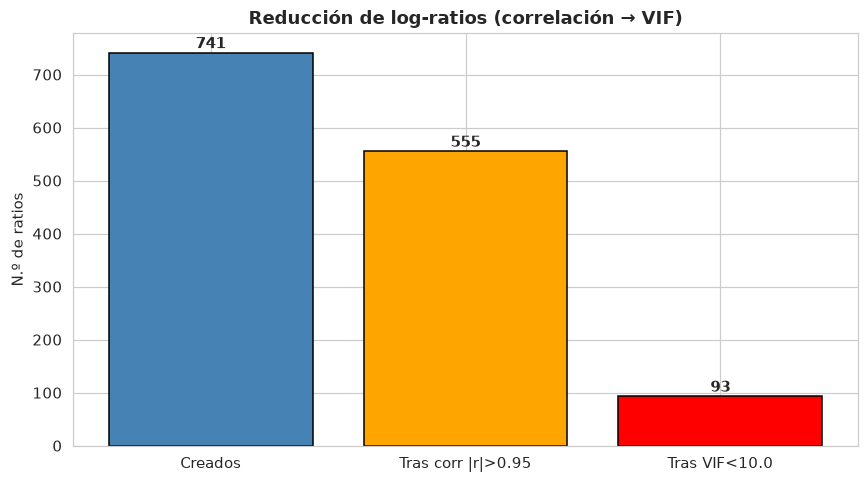

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
b = ax.bar(resumen_fe['Etapa'], resumen_fe['N_ratios'],
           color=['steelblue', 'orange', 'red'], edgecolor='black')
for r in b:
    ax.text(r.get_x()+r.get_width()/2, r.get_height()+2, f'{int(r.get_height())}',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('N.º de ratios'); ax.set_title('Reducción de log-ratios (correlación → VIF)', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint2/fe_reduccion_ratios.png', bbox_inches='tight'); plt.show()

## Clustering sobre elementos no económicos

In [9]:
def features_cluster(Xtr_esp, Xte_esp, etiqueta):
    '''Genera 5 features de cluster (KMeans+GMM+DBSCAN) en el espacio dado.
    Devuelve (feats_train, feats_test, info, curvas) donde curvas={sils, bics, kdist}.'''
    sc = StandardScaler().fit(Xtr_esp)
    Ztr, Zte = sc.transform(Xtr_esp), sc.transform(Xte_esp)

    # KMeans: k por silhouette (criterio interno de configuración)
    sils = [silhouette_score(Ztr, KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(Ztr))
            for k in range(2, 11)]
    k_km = int(np.argmax(sils)) + 2
    km = KMeans(n_clusters=k_km, random_state=SEED, n_init=10).fit(Ztr)

    # GMM: k por BIC
    bics = [GaussianMixture(n_components=k, random_state=SEED).fit(Ztr).bic(Ztr) for k in range(2, 11)]
    k_gmm = int(np.argmin(bics)) + 2
    gm = GaussianMixture(n_components=k_gmm, random_state=SEED).fit(Ztr)

    # DBSCAN: eps por percentil 90 de k-distancias
    nn = NearestNeighbors(n_neighbors=10).fit(Ztr)
    kdist = np.sort(nn.kneighbors(Ztr)[0][:, -1])
    eps = float(np.percentile(kdist, 90))
    db_tr = DBSCAN(eps=eps, min_samples=10).fit_predict(Ztr)
    db_te = DBSCAN(eps=eps, min_samples=10).fit_predict(Zte)

    def dist_centroides(Z):
        return np.min(np.linalg.norm(Z[:, None, :] - km.cluster_centers_[None, :, :], axis=2), axis=1)

    ftr = pd.DataFrame({
        f'kmeans_label_{etiqueta}': km.labels_,
        f'kmeans_dist_{etiqueta}': dist_centroides(Ztr),
        f'gmm_label_{etiqueta}': gm.predict(Ztr),
        f'gmm_prob_max_{etiqueta}': gm.predict_proba(Ztr).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_tr == -1).astype(int),
    }, index=Xtr_esp.index)
    fte = pd.DataFrame({
        f'kmeans_label_{etiqueta}': km.predict(Zte),
        f'kmeans_dist_{etiqueta}': dist_centroides(Zte),
        f'gmm_label_{etiqueta}': gm.predict(Zte),
        f'gmm_prob_max_{etiqueta}': gm.predict_proba(Zte).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_te == -1).astype(int),
    }, index=Xte_esp.index)
    info = {'espacio': etiqueta, 'k_kmeans': k_km, 'k_gmm': k_gmm,
            'eps_dbscan': round(eps, 3), 'n_outliers_train': int((db_tr == -1).sum())}
    curvas = {'sils': sils, 'bics': bics, 'kdist': kdist}
    return ftr, fte, info, curvas

# Espacio RAW y LOG sobre los no económicos
Xtr_raw = X_train[NO_ECON].copy()
Xte_raw = X_test[NO_ECON].copy()
Xtr_log = np.log1p(X_train[NO_ECON].clip(lower=0))
Xte_log = np.log1p(X_test[NO_ECON].clip(lower=0))

cl_raw_tr, cl_raw_te, info_raw, curvas_raw = features_cluster(Xtr_raw, Xte_raw, 'raw')
cl_log_tr, cl_log_te, info_log, curvas_log = features_cluster(Xtr_log, Xte_log, 'log')

tabla_clust = pd.DataFrame([info_raw, info_log]).set_index('espacio')
tabla_clust.to_csv('outputs_sprint2/clustering_config_raw_log.csv')
print('Configuración de clustering por espacio (k y eps elegidos internamente):')
print(tabla_clust.to_string())

Configuración de clustering por espacio (k y eps elegidos internamente):
         k_kmeans  k_gmm  eps_dbscan  n_outliers_train
espacio                                               
raw             2      5       4.749               105
log             2      4       5.052                86


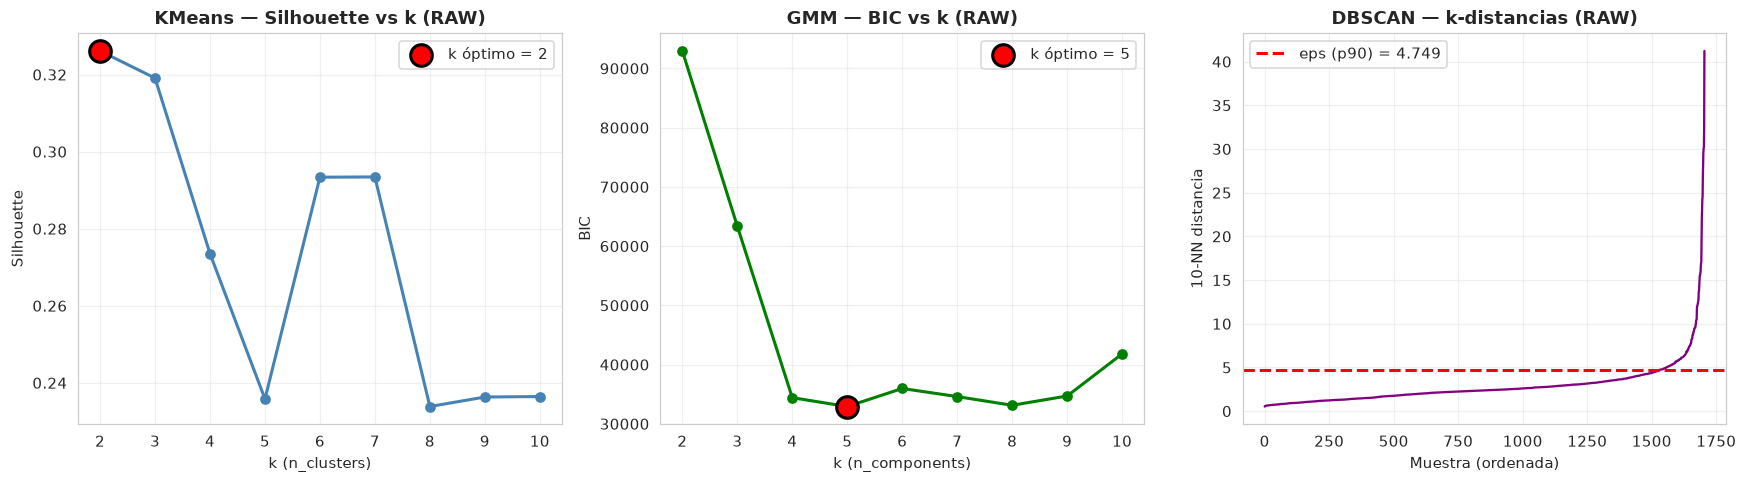

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ks = list(range(2, 11))

# KMeans: silhouette vs k
axes[0].plot(ks, curvas_raw['sils'], marker='o', lw=2, color='steelblue')
axes[0].scatter([info_raw['k_kmeans']], [max(curvas_raw['sils'])], s=200, color='red',
                edgecolors='black', linewidths=2, zorder=5, label=f'k óptimo = {info_raw["k_kmeans"]}')
axes[0].set_xlabel('k (n_clusters)'); axes[0].set_ylabel('Silhouette')
axes[0].set_title('KMeans — Silhouette vs k (RAW)', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# GMM: BIC vs k (menor BIC = mejor)
axes[1].plot(ks, curvas_raw['bics'], marker='o', lw=2, color='green')
axes[1].scatter([info_raw['k_gmm']], [min(curvas_raw['bics'])], s=200, color='red',
                edgecolors='black', linewidths=2, zorder=5, label=f'k óptimo = {info_raw["k_gmm"]}')
axes[1].set_xlabel('k (n_components)'); axes[1].set_ylabel('BIC')
axes[1].set_title('GMM — BIC vs k (RAW)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# DBSCAN: k-distancias ordenadas
axes[2].plot(curvas_raw['kdist'], lw=1.5, color='purple')
axes[2].axhline(info_raw['eps_dbscan'], color='red', linestyle='--', lw=2,
                label=f'eps (p90) = {info_raw["eps_dbscan"]:.3f}')
axes[2].set_xlabel('Muestra (ordenada)'); axes[2].set_ylabel('10-NN distancia')
axes[2].set_title('DBSCAN — k-distancias (RAW)', fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs_sprint2/clustering_sustento_raw.png', bbox_inches='tight')
plt.show()

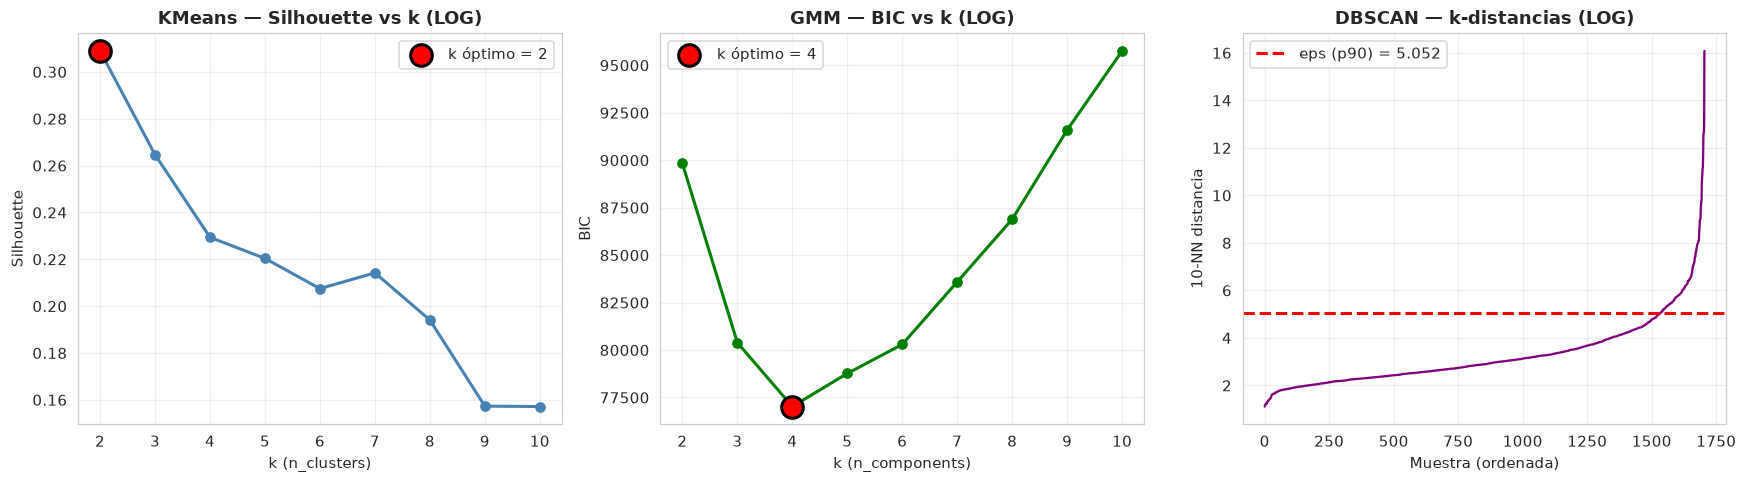

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# KMeans: silhouette vs k
axes[0].plot(ks, curvas_log['sils'], marker='o', lw=2, color='steelblue')
axes[0].scatter([info_log['k_kmeans']], [max(curvas_log['sils'])], s=200, color='red',
                edgecolors='black', linewidths=2, zorder=5, label=f'k óptimo = {info_log["k_kmeans"]}')
axes[0].set_xlabel('k (n_clusters)'); axes[0].set_ylabel('Silhouette')
axes[0].set_title('KMeans — Silhouette vs k (LOG)', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# GMM: BIC vs k
axes[1].plot(ks, curvas_log['bics'], marker='o', lw=2, color='green')
axes[1].scatter([info_log['k_gmm']], [min(curvas_log['bics'])], s=200, color='red',
                edgecolors='black', linewidths=2, zorder=5, label=f'k óptimo = {info_log["k_gmm"]}')
axes[1].set_xlabel('k (n_components)'); axes[1].set_ylabel('BIC')
axes[1].set_title('GMM — BIC vs k (LOG)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# DBSCAN: k-distancias ordenadas
axes[2].plot(curvas_log['kdist'], lw=1.5, color='purple')
axes[2].axhline(info_log['eps_dbscan'], color='red', linestyle='--', lw=2,
                label=f'eps (p90) = {info_log["eps_dbscan"]:.3f}')
axes[2].set_xlabel('Muestra (ordenada)'); axes[2].set_ylabel('10-NN distancia')
axes[2].set_title('DBSCAN — k-distancias (LOG)', fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs_sprint2/clustering_sustento_log.png', bbox_inches='tight')
plt.show()

## Experimentos A/B

In [12]:
# Definición de los 6 experimentos (train, test)
# Bloques reutilizables
E1_tr = pd.concat([X_train_logbase, R_train_c[RATIOS_SEL]], axis=1)
E1_te = pd.concat([X_test_logbase,  R_test_c[RATIOS_SEL]],  axis=1)
E2_tr = pd.concat([X_train_logbase, cl_raw_tr], axis=1)
E2_te = pd.concat([X_test_logbase,  cl_raw_te], axis=1)
E3_tr = pd.concat([X_train_logbase, R_train_c[RATIOS_SEL], cl_raw_tr], axis=1)
E3_te = pd.concat([X_test_logbase,  R_test_c[RATIOS_SEL],  cl_raw_te], axis=1)
E4_tr = pd.concat([X_train_logbase, cl_log_tr], axis=1)
E4_te = pd.concat([X_test_logbase,  cl_log_te], axis=1)
E5_tr = pd.concat([X_train_logbase, R_train_c[RATIOS_SEL], cl_log_tr], axis=1)
E5_te = pd.concat([X_test_logbase,  R_test_c[RATIOS_SEL],  cl_log_te], axis=1)

sets = {
    'E0 Base':              (X_train, X_test),
    'E1 +FE':               (E1_tr, E1_te),
    'E2 +Cluster RAW':      (E2_tr, E2_te),
    'E3 +FE+Cluster RAW':   (E3_tr, E3_te),
    'E4 +Cluster LOG':      (E4_tr, E4_te),
    'E5 +FE+Cluster LOG':   (E5_tr, E5_te),
}
for nombre, (Xtr_, _) in sets.items():
    print(f'{nombre:24s}: {Xtr_.shape[1]} features')

E0 Base                 : 46 features
E1 +FE                  : 139 features
E2 +Cluster RAW         : 51 features
E3 +FE+Cluster RAW      : 144 features
E4 +Cluster LOG         : 51 features
E5 +FE+Cluster LOG      : 144 features


In [13]:
print('\nEvaluando 6 experimentos × 11 modelos por F1_CV ...')
t0 = time.time()
f1_ab = pd.DataFrame(index=list(sets.keys()), columns=MODELOS, dtype=float)
for exp, (Xtr_, _) in sets.items():
    for mod in MODELOS:
        mu, _ = f1_cv(mod, Xtr_, y_train, balanceo=BAL_POR_MOD[mod])
        f1_ab.loc[exp, mod] = mu
    print(f'  {exp} completado')
print(f'Terminado en {time.time()-t0:.0f}s')
f1_ab = f1_ab.astype(float).round(4)
f1_ab.to_csv('outputs_sprint2/experimentos_f1_cv.csv')

print('\nExperimentos A/B — F1_CV (media) · MÉTRICA PRIMARIA')
f1_ab.style.apply(resaltar_maximo, axis=0).format('{:.4f}')


Evaluando 6 experimentos × 11 modelos por F1_CV ...
  E0 Base completado
  E1 +FE completado
  E2 +Cluster RAW completado
  E3 +FE+Cluster RAW completado
  E4 +Cluster LOG completado
  E5 +FE+Cluster LOG completado
Terminado en 302s

Experimentos A/B — F1_CV (media) · MÉTRICA PRIMARIA


,KNN,Reg. Logística,SVM (RBF),MLP,Árbol de Decisión,Random Forest,ExtraTrees,HistGradientBoosting,XGBoost,LightGBM,CatBoost
E0 Base,0.4876,0.5493,0.4500,0.6436,0.5701,0.6831,0.6498,0.7226,0.7201,0.7245,0.7277
E1 +FE,0.5695,0.6625,0.6639,0.6771,0.5227,0.6500,0.6769,0.6825,0.6913,0.7244,0.6906
E2 +Cluster RAW,0.5638,0.6566,0.6499,0.7052,0.5505,0.6786,0.6957,0.7307,0.7177,0.7259,0.7040
E3 +FE+Cluster RAW,0.5659,0.6624,0.6679,0.6849,0.4884,0.6581,0.6430,0.6929,0.7295,0.7153,0.7058
E4 +Cluster LOG,0.5363,0.6454,0.6499,0.6715,0.5248,0.6633,0.6914,0.7179,0.7032,0.7056,0.6927
E5 +FE+Cluster LOG,0.5377,0.6642,0.6730,0.6773,0.5515,0.6572,0.6588,0.6855,0.7046,0.7402,0.6886


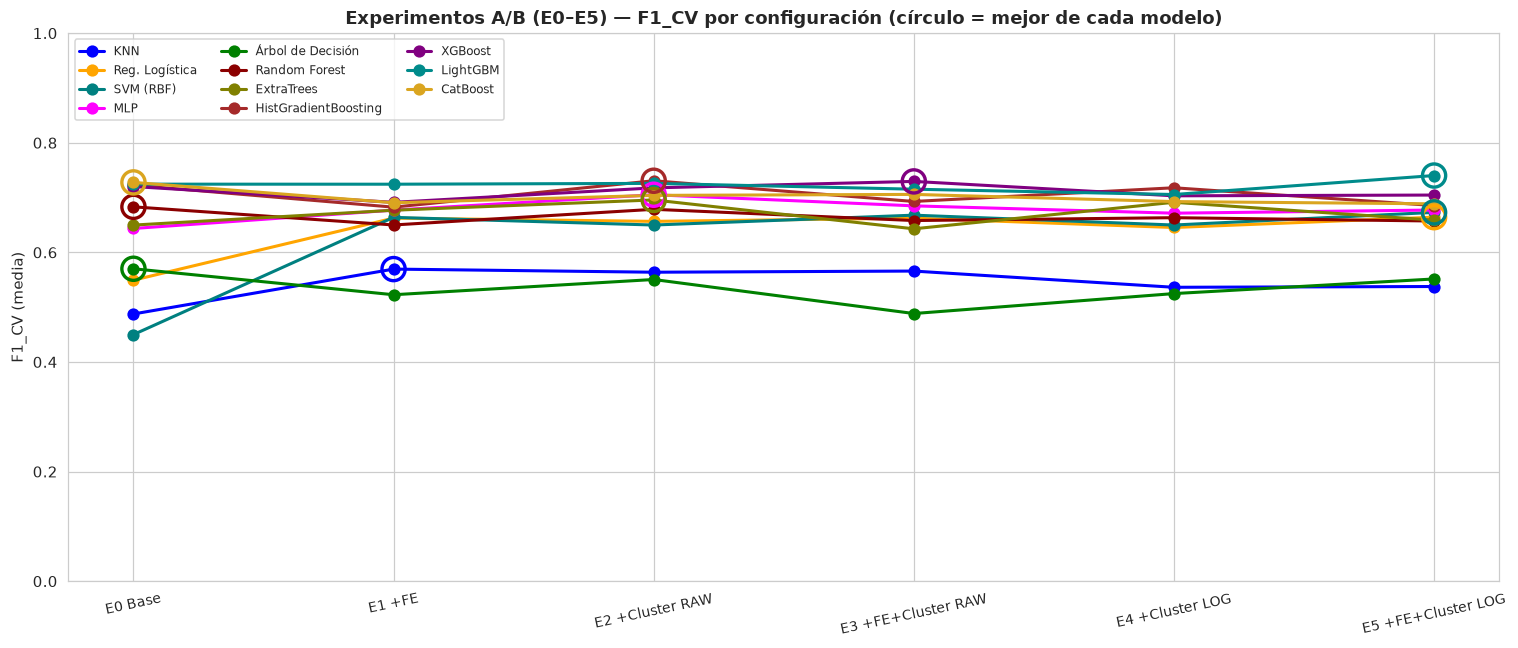

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(f1_ab.index))
for mod in MODELOS:
    ax.plot(x, f1_ab[mod].values, marker='o', lw=2, markersize=7, color=MODEL_COLORS[mod], label=mod)
    xi = int(np.argmax(f1_ab[mod].values))
    ax.scatter([xi], [f1_ab[mod].values[xi]], s=230, facecolors='none',
               edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(list(f1_ab.index), fontsize=9, rotation=12)
ax.set_ylabel('F1_CV (media)'); ax.set_ylim(0, 1)
ax.set_title('Experimentos A/B (E0–E5) — F1_CV por configuración (círculo = mejor de cada modelo)',
             fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout(); plt.savefig('outputs_sprint2/experimentos_f1_cv_comparacion.png', bbox_inches='tight'); plt.show()

In [15]:
mejor_set_mod = {mod: f1_ab[mod].idxmax() for mod in MODELOS}
resumen_ab = pd.DataFrame({
    'Mejor set':      [mejor_set_mod[m] for m in MODELOS],
    'F1_CV (mejor)':  [round(f1_ab[m].max(), 4) for m in MODELOS],
    'F1_CV (E0)':     [round(f1_ab.loc['E0 Base', m], 4) for m in MODELOS],
}, index=MODELOS)
resumen_ab['Δ F1_CV'] = (resumen_ab['F1_CV (mejor)'] - resumen_ab['F1_CV (E0)']).round(4)
resumen_ab.to_csv('outputs_sprint2/experimentos_mejor_set.csv')
print('\nMejor set por modelo (por F1_CV):')
resumen_ab


Mejor set por modelo (por F1_CV):


,Mejor set,F1_CV (mejor),F1_CV (E0),Δ F1_CV
KNN,E1 +FE,0.5695,0.4876,0.0819
Reg. Logística,E5 +FE+Cluster LOG,0.6642,0.5493,0.1149
SVM (RBF),E5 +FE+Cluster LOG,0.6730,0.4500,0.2230
MLP,E2 +Cluster RAW,0.7052,0.6436,0.0616
Árbol de Decisión,E0 Base,0.5701,0.5701,0.0000
Random Forest,E0 Base,0.6831,0.6831,0.0000
ExtraTrees,E2 +Cluster RAW,0.6957,0.6498,0.0459
HistGradientBoosting,E2 +Cluster RAW,0.7307,0.7226,0.0081
XGBoost,E3 +FE+Cluster RAW,0.7295,0.7201,0.0094
LightGBM,E5 +FE+Cluster LOG,0.7402,0.7245,0.0157


## Optuna

In [16]:
def espacio_optuna(mod, trial):
    if mod == 'KNN':
        return {'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)}
    if mod == 'Reg. Logística':
        return {'C': trial.suggest_float('C', 0.01, 10, log=True),
                'max_iter': trial.suggest_categorical('max_iter', [500, 1000])}
    if mod == 'SVM (RBF)':
        return {'C': trial.suggest_float('C', 0.1, 10, log=True),
                'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])}
    if mod == 'MLP':
        return {'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [(50,), (100,), (100, 50)]),
                'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),
                'max_iter': trial.suggest_categorical('max_iter', [300, 500])}
    if mod == 'Árbol de Decisión':
        return {'max_depth': trial.suggest_int('max_depth', 3, 20),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20)}
    if mod == 'Random Forest':
        return {'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 5, 30),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)}
    if mod == 'ExtraTrees':
        return {'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 5, 30),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)}
    if mod == 'HistGradientBoosting':
        return {'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'max_iter': trial.suggest_int('max_iter', 50, 200),
                'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 50),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 50),
                'l2_regularization': trial.suggest_float('l2_regularization', 0, 2)}
    if mod == 'XGBoost':
        return {'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': trial.suggest_int('n_estimators', 50, 200),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0)}
    if mod == 'LightGBM':
        return {'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': trial.suggest_int('n_estimators', 50, 200),
                'num_leaves': trial.suggest_int('num_leaves', 20, 100),
                'min_child_samples': trial.suggest_int('min_child_samples', 10, 50)}
    if mod == 'CatBoost':
        return {'iterations': trial.suggest_int('iterations', 50, 200),
                'depth': trial.suggest_int('depth', 4, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True)}
    raise ValueError(mod)

def crear_clf_optuna(mod, params):
    if mod == 'KNN':                  return KNeighborsClassifier(**params)
    if mod == 'Reg. Logística':       return LogisticRegression(**params, random_state=SEED)
    if mod == 'SVM (RBF)':            return SVC(kernel='rbf', probability=True, **params, random_state=SEED)
    if mod == 'MLP':                  return MLPClassifier(**params, random_state=SEED)
    if mod == 'Árbol de Decisión':    return DecisionTreeClassifier(**params, random_state=SEED)
    if mod == 'Random Forest':        return RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)
    if mod == 'ExtraTrees':           return ExtraTreesClassifier(**params, random_state=SEED, n_jobs=-1)
    if mod == 'HistGradientBoosting': return HistGradientBoostingClassifier(**params, random_state=SEED)
    if mod == 'XGBoost':              return xgb.XGBClassifier(**params, random_state=SEED, eval_metric='logloss',
                                                               tree_method='hist', n_jobs=-1)
    if mod == 'LightGBM':             return lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, n_jobs=-1)
    if mod == 'CatBoost':             return CatBoostClassifier(**params, random_seed=SEED, verbose=0,
                                                               allow_writing_files=False)
    raise ValueError(mod)

def pipeline_optuna(mod, params, balanceo):
    pasos = [('sc', StandardScaler())]
    bal = crear_balanceador(balanceo)
    if bal is not None:
        pasos.append(('bal', bal))
    pasos.append(('clf', crear_clf_optuna(mod, params)))
    return ImbPipeline(pasos)

def make_objective(mod, Xtr_m, bal_m):
    def objective(trial):
        params = espacio_optuna(mod, trial)
        pipe = pipeline_optuna(mod, params, bal_m)
        sc = cross_val_score(pipe, Xtr_m, y_train, cv=CV5, scoring='f1', n_jobs=-1)
        trial.set_user_attr('std', float(sc.std()))  # std entre folds del trial
        return sc.mean()
    return objective

N_TRIALS = 100
studies, optuna_res = {}, {}
print(f'Optuna: optimizando los {len(MODELOS)} modelos ({N_TRIALS} trials c/u) en su mejor set ...\n')
t_glob = time.time()
for mod in MODELOS:
    set_m = mejor_set_mod[mod]
    Xtr_m, _ = sets[set_m]
    bal_m = BAL_POR_MOD[mod]
    t0 = time.time()
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
    study.optimize(make_objective(mod, Xtr_m, bal_m), n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    studies[mod] = study
    # std entre folds: default recomputado con f1_cv; Optuna desde el user_attr del mejor trial
    f1_def, std_def = f1_cv(mod, Xtr_m, y_train, balanceo=bal_m)
    std_opt = float(study.best_trial.user_attrs.get('std', np.nan))
    optuna_res[mod] = {'set': set_m, 'bal': bal_m,
                       'f1_default': float(f1_def), 'std_default': float(std_def),
                       'f1_optuna': float(study.best_value), 'std_optuna': std_opt,
                       'params': study.best_params}
    print(f'  {mod:22s} set={set_m:20s} F1_def={f1_def:.4f}±{std_def:.4f} → '
          f'F1_opt={study.best_value:.4f}±{std_opt:.4f} (Δ={study.best_value-f1_def:+.4f}, {time.time()-t0:.0f}s)')
print(f'\nOptuna total: {time.time()-t_glob:.0f}s')

Optuna: optimizando los 11 modelos (100 trials c/u) en su mejor set ...

  KNN                    set=E1 +FE               F1_def=0.5695±0.0467 → F1_opt=0.5892±0.0330 (Δ=+0.0196, 21s)
  Reg. Logística         set=E5 +FE+Cluster LOG   F1_def=0.6642±0.0262 → F1_opt=0.6681±0.0255 (Δ=+0.0039, 25s)
  SVM (RBF)              set=E5 +FE+Cluster LOG   F1_def=0.6730±0.0440 → F1_opt=0.6754±0.0438 (Δ=+0.0024, 362s)
  MLP                    set=E2 +Cluster RAW      F1_def=0.7052±0.0577 → F1_opt=0.7069±0.0572 (Δ=+0.0017, 811s)
  Árbol de Decisión      set=E0 Base              F1_def=0.5701±0.0302 → F1_opt=0.5853±0.0183 (Δ=+0.0152, 36s)
  Random Forest          set=E0 Base              F1_def=0.6831±0.0253 → F1_opt=0.6921±0.0290 (Δ=+0.0091, 409s)
  ExtraTrees             set=E2 +Cluster RAW      F1_def=0.6957±0.0083 → F1_opt=0.7308±0.0233 (Δ=+0.0352, 266s)
  HistGradientBoosting   set=E2 +Cluster RAW      F1_def=0.7307±0.0372 → F1_opt=0.7428±0.0402 (Δ=+0.0121, 203s)
  XGBoost                set=E3 +F

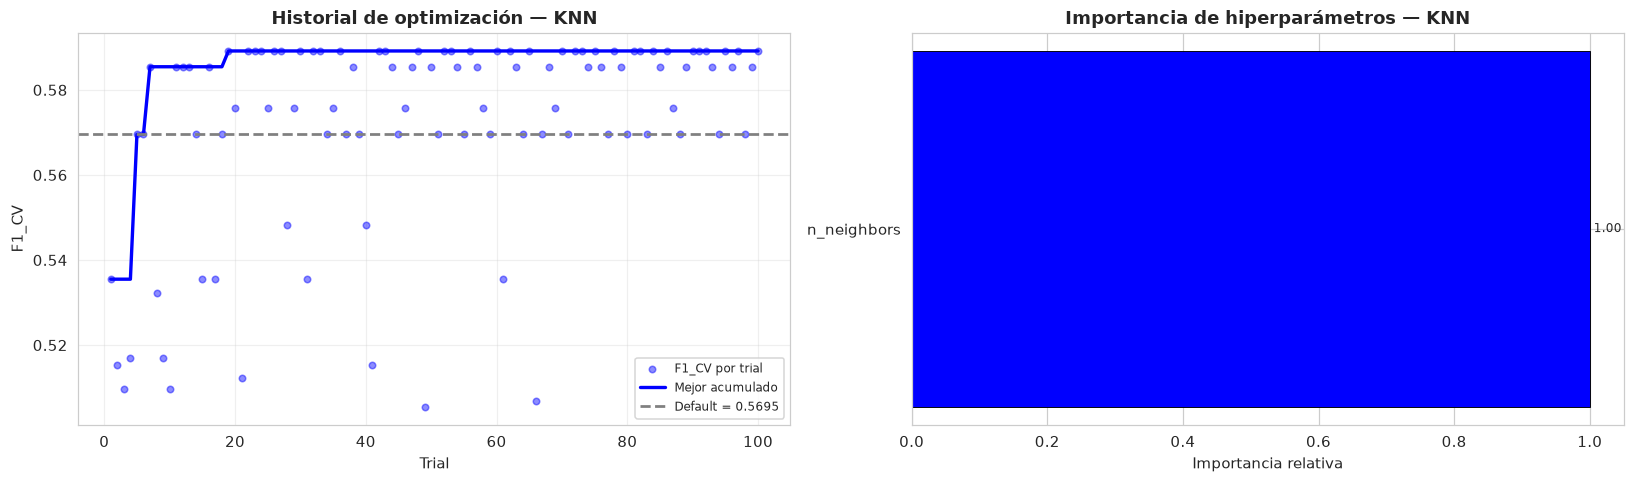

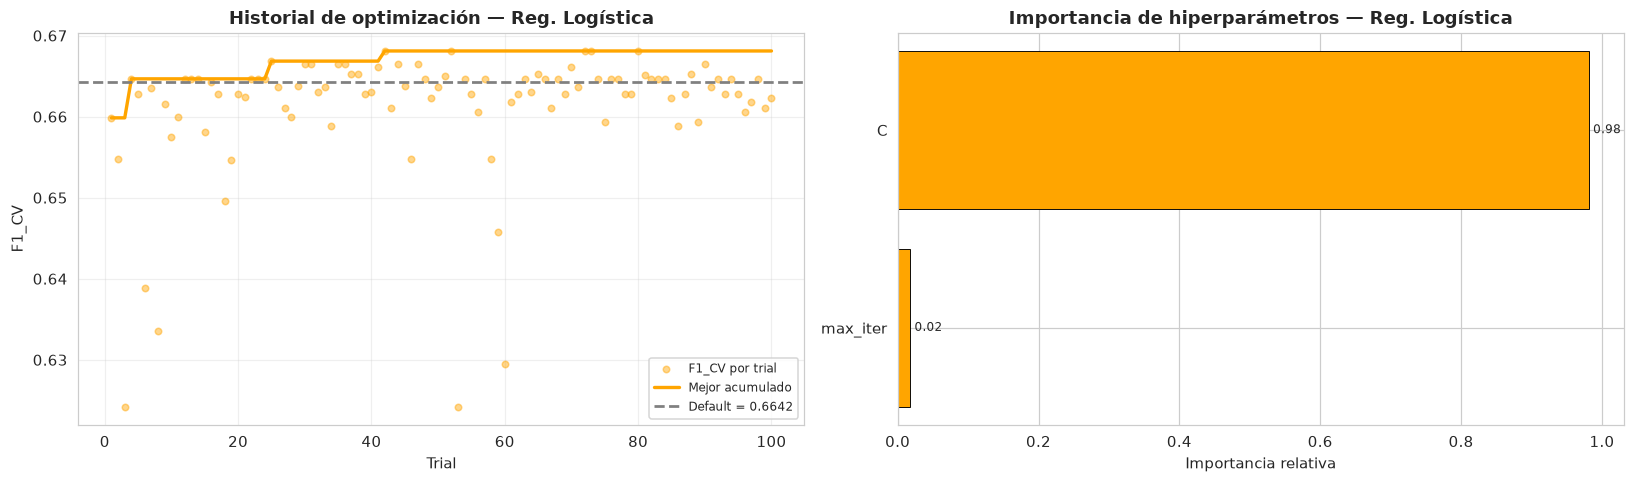

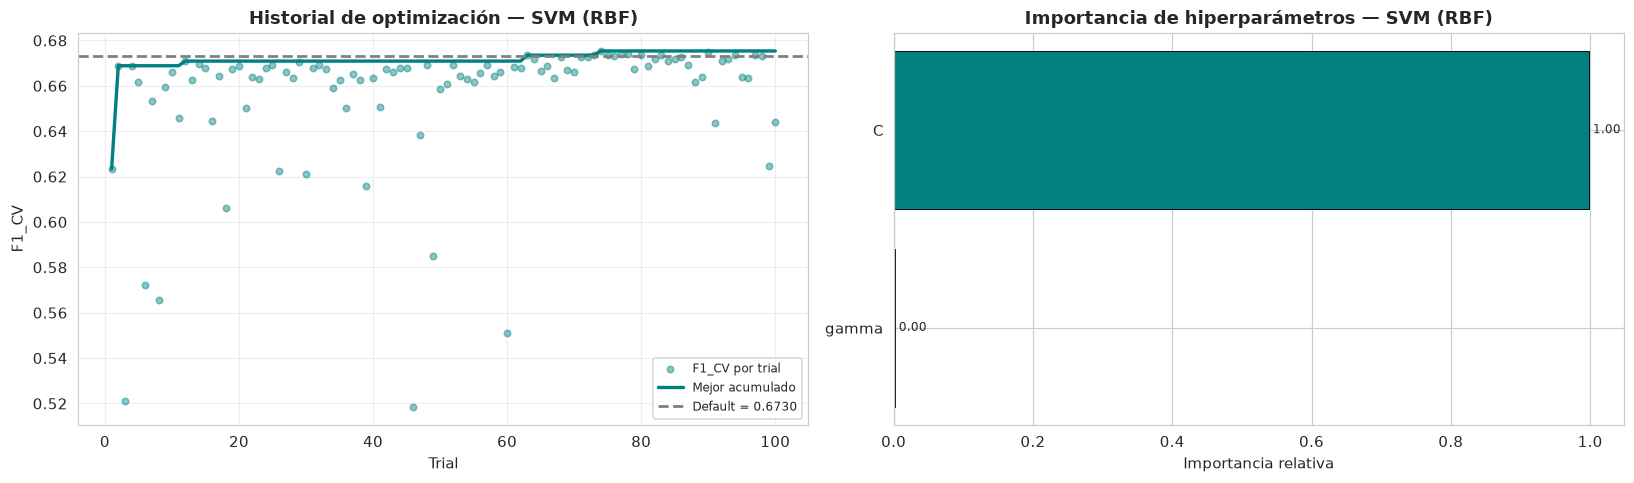

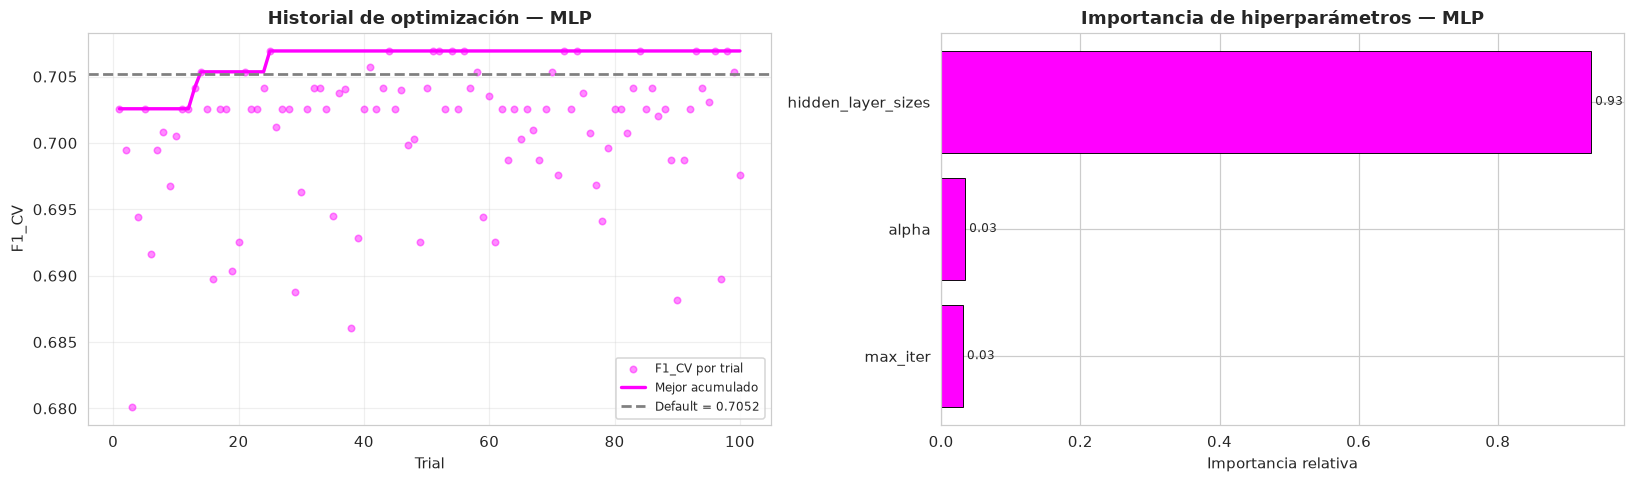

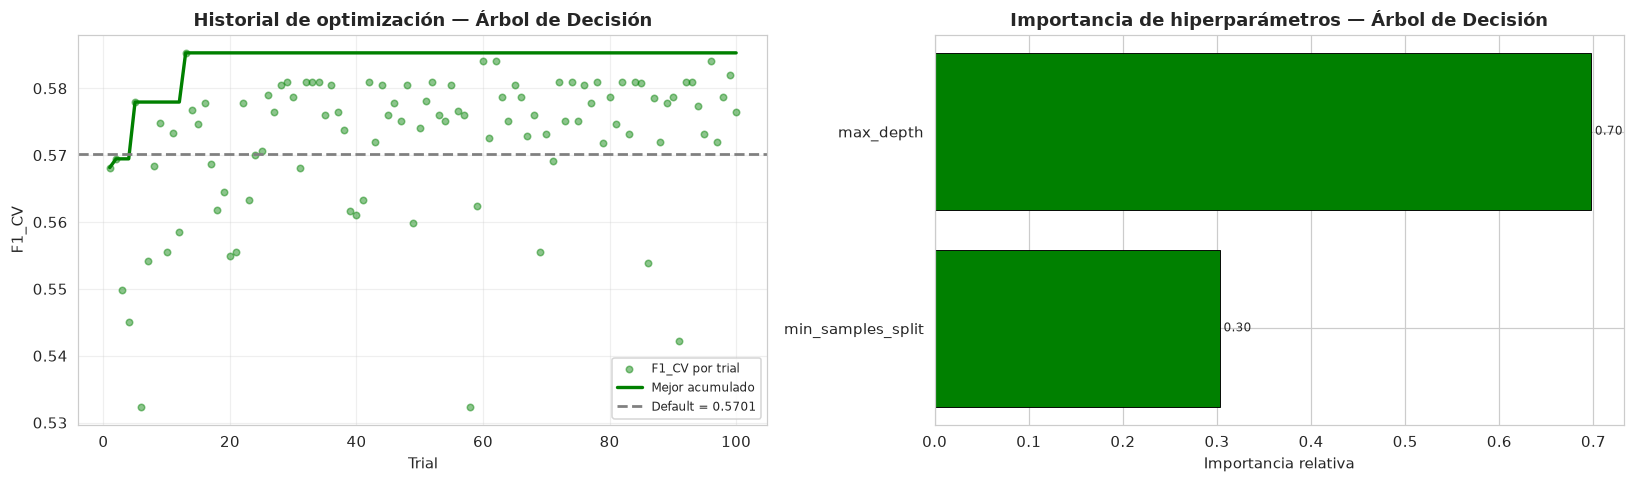

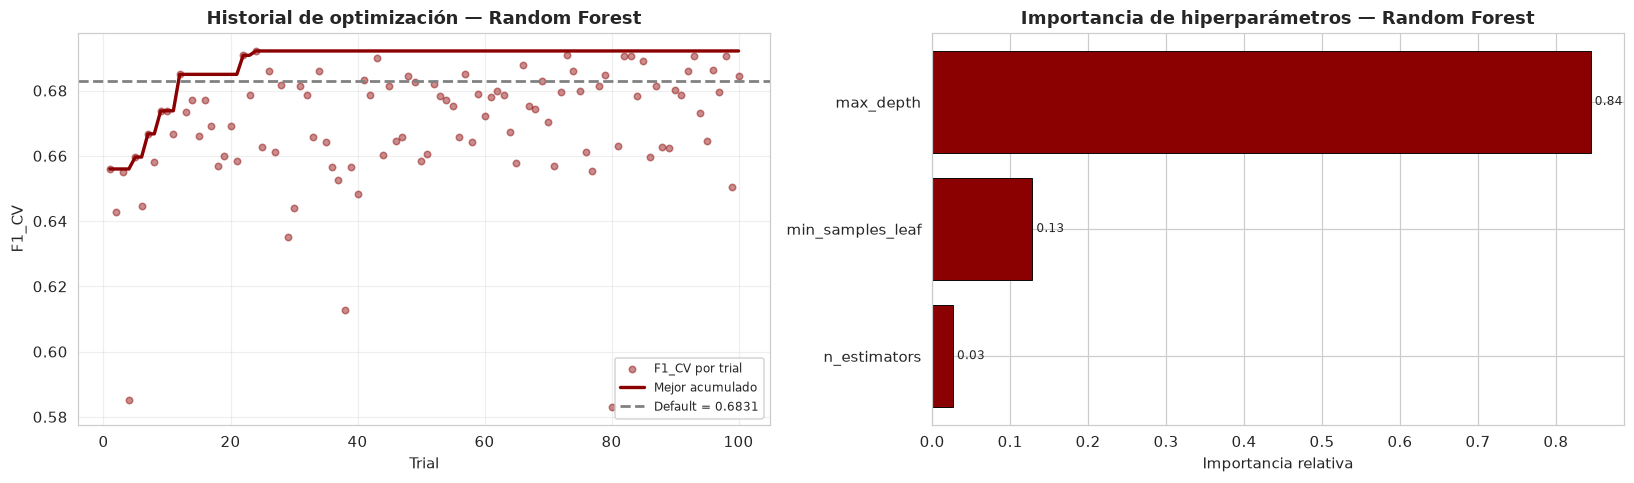

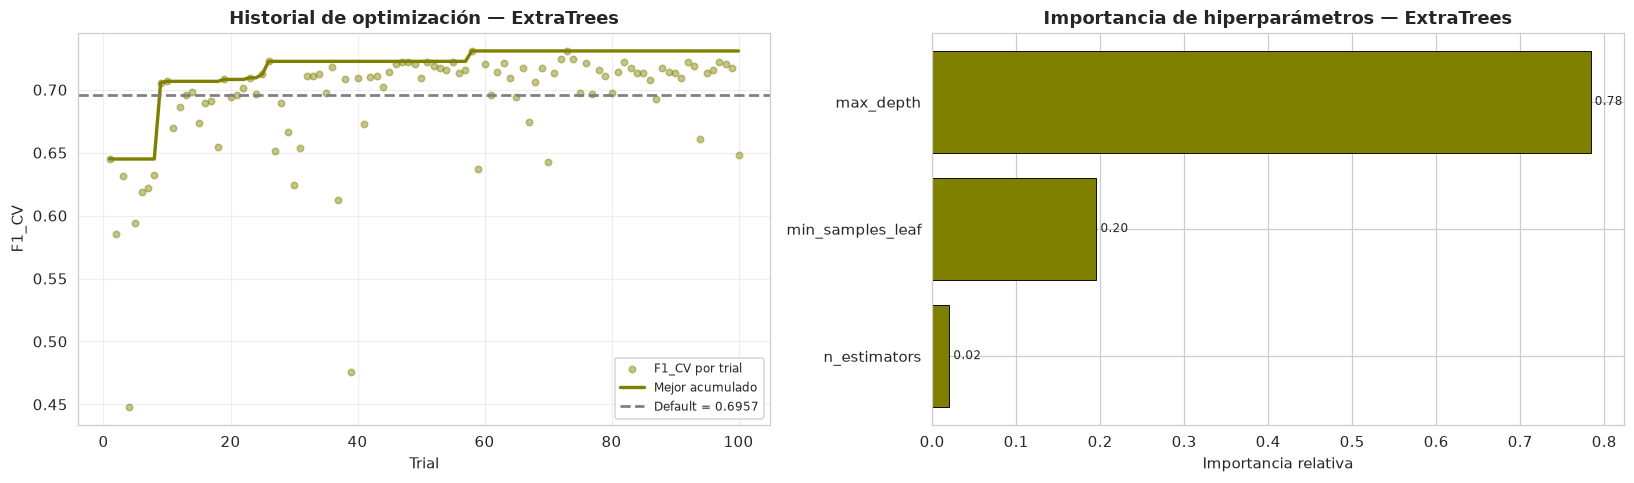

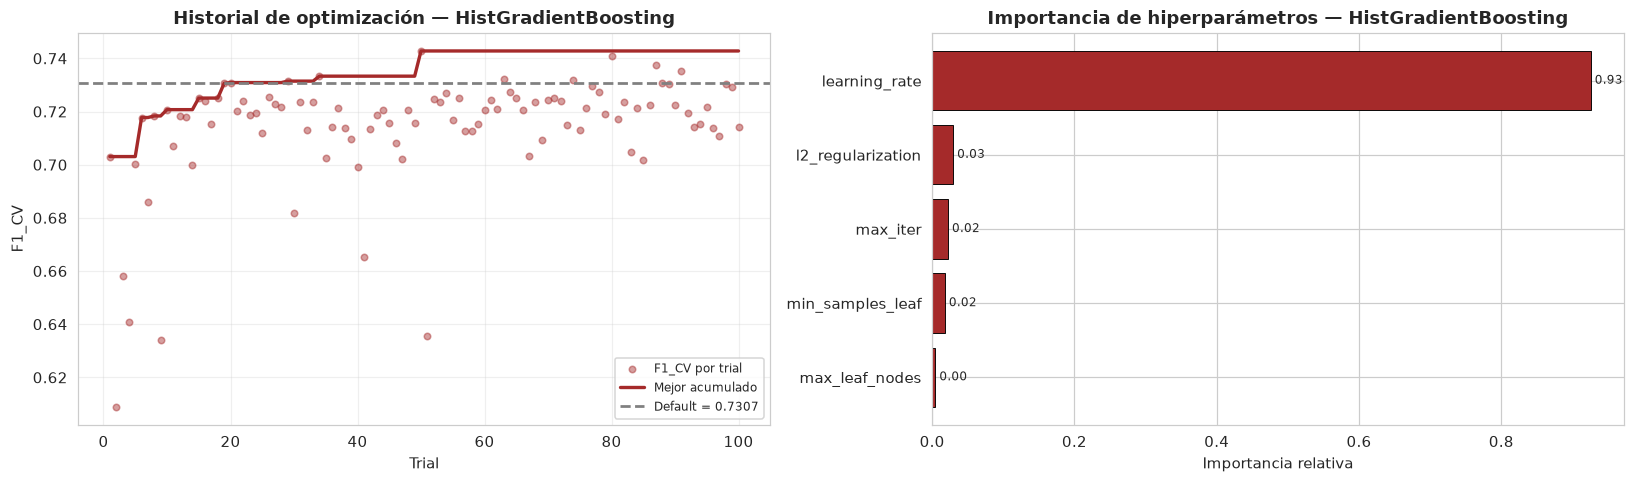

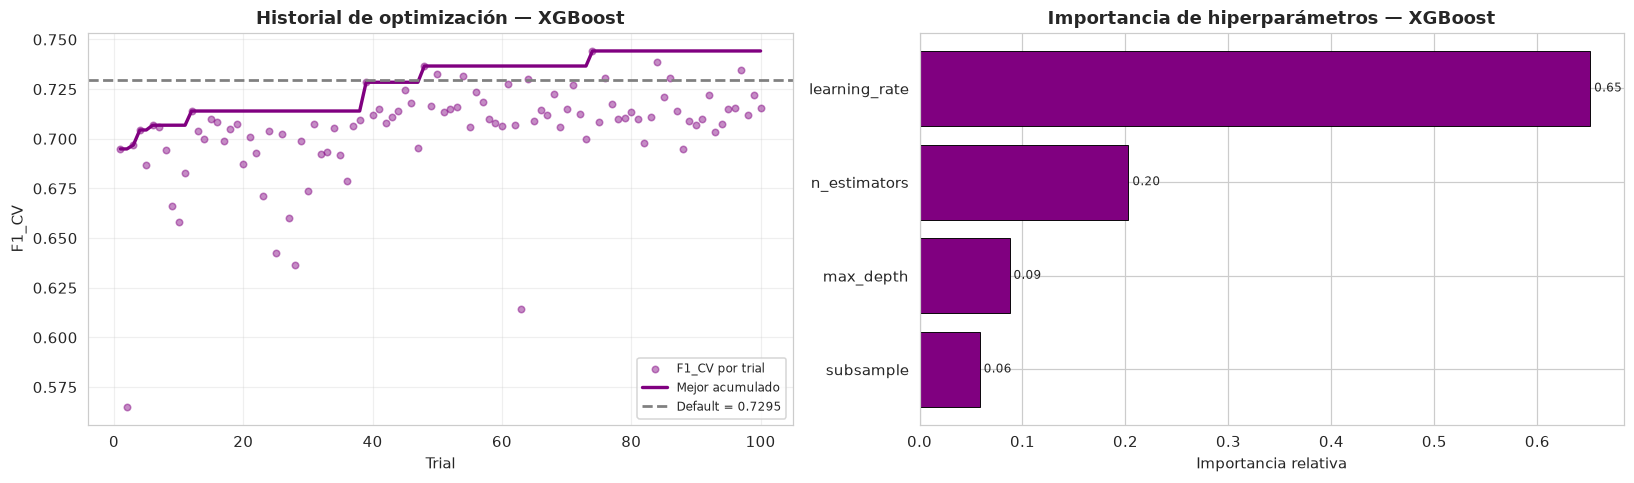

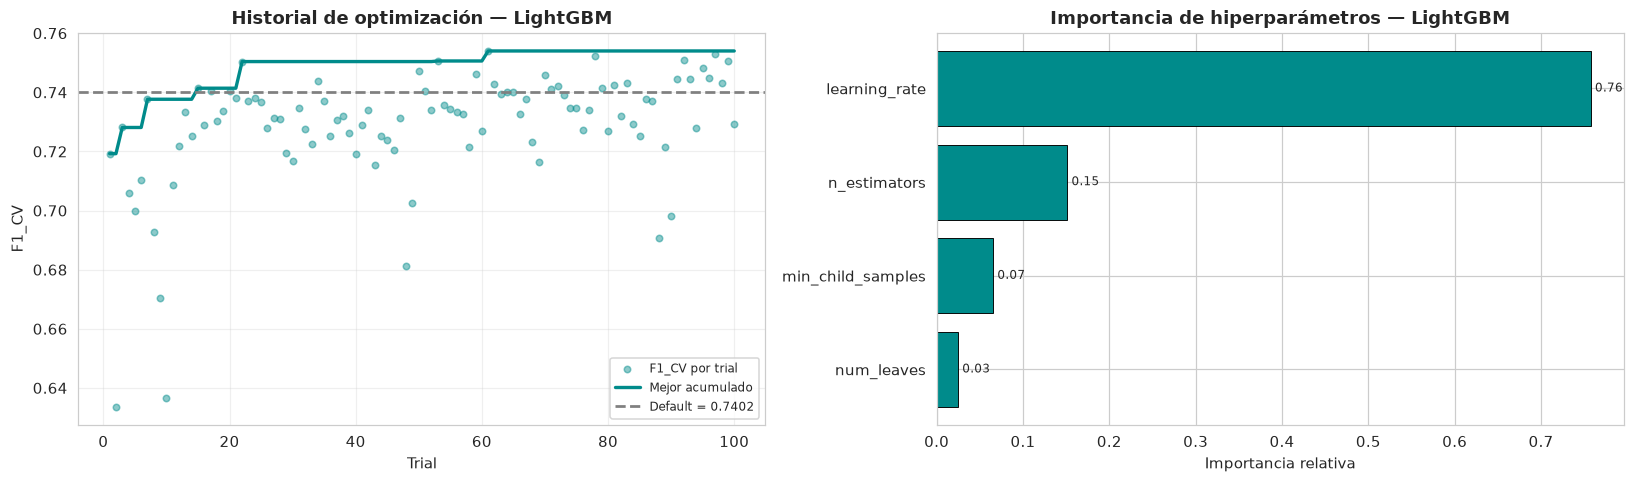

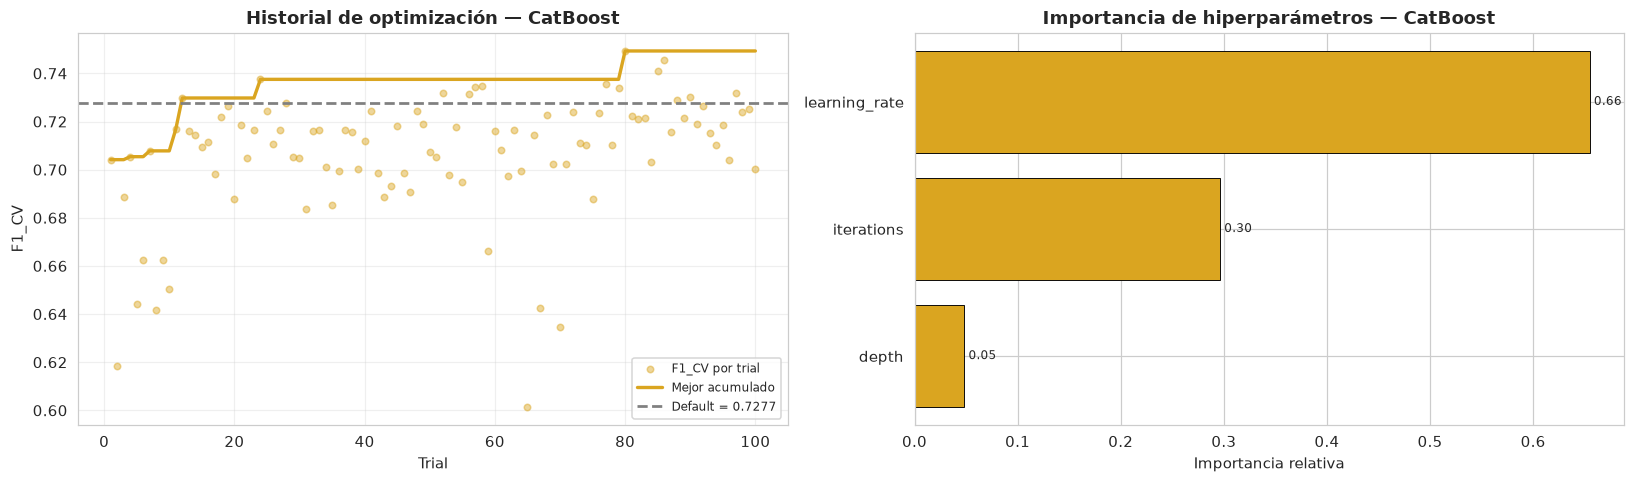

In [17]:
import re
def slug(txt):
    return re.sub(r'[^a-z0-9]+', '_', txt.lower()).strip('_')

def plot_optuna_modelo(study, mod, f1_def):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    color = MODEL_COLORS[mod]
    # (izq) historial de optimización
    vals = [t.value for t in study.trials if t.value is not None]
    best_run = np.maximum.accumulate(vals)
    xs = range(1, len(vals) + 1)
    axes[0].scatter(list(xs), vals, s=18, alpha=0.45, color=color, label='F1_CV por trial')
    axes[0].plot(list(xs), best_run, lw=2.2, color=color, label='Mejor acumulado')
    axes[0].axhline(f1_def, ls='--', lw=1.8, color='gray', label=f'Default = {f1_def:.4f}')
    axes[0].set_xlabel('Trial'); axes[0].set_ylabel('F1_CV')
    axes[0].set_title(f'Historial de optimización — {mod}', fontweight='bold')
    axes[0].legend(fontsize=8, loc='lower right'); axes[0].grid(True, alpha=0.3)
    # (der) importancia de hiperparámetros
    try:
        imp = optuna.importance.get_param_importances(study)
        nombres = list(imp.keys())[::-1]; valores = [imp[k] for k in nombres]
        axes[1].barh(nombres, valores, color=color, edgecolor='black', linewidth=0.6)
        for i, v in enumerate(valores):
            axes[1].text(v, i, f' {v:.2f}', va='center', fontsize=8)
        axes[1].set_xlabel('Importancia relativa')
    except Exception as e:
        axes[1].text(0.5, 0.5, f'Importancia no disponible\n({e})', ha='center', va='center')
        axes[1].axis('off')
    axes[1].set_title(f'Importancia de hiperparámetros — {mod}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'outputs_sprint2/optuna_{slug(mod)}.png', bbox_inches='tight')
    plt.show()

for mod in MODELOS:
    plot_optuna_modelo(studies[mod], mod, optuna_res[mod]['f1_default'])

## Comparación de resultados

In [18]:
tabla_opt = pd.DataFrame({
    'Mejor set':        [optuna_res[m]['set'] for m in MODELOS],
    'Balanceo':         [optuna_res[m]['bal'] for m in MODELOS],
    'F1_CV (default)':  [round(optuna_res[m]['f1_default'], 4) for m in MODELOS],
    '± std (def)':      [round(optuna_res[m]['std_default'], 4) for m in MODELOS],
    'F1_CV (Optuna)':   [round(optuna_res[m]['f1_optuna'], 4) for m in MODELOS],
    '± std (opt)':      [round(optuna_res[m]['std_optuna'], 4) for m in MODELOS],
}, index=MODELOS)
tabla_opt['Δ Optuna'] = (tabla_opt['F1_CV (Optuna)'] - tabla_opt['F1_CV (default)']).round(4)
# F1_CV (mejor) y su std: el std corresponde a la config elegida (Optuna si mejora, si no default)
usa_opt = tabla_opt['F1_CV (Optuna)'] >= tabla_opt['F1_CV (default)']
tabla_opt['F1_CV (mejor)'] = np.where(usa_opt, tabla_opt['F1_CV (Optuna)'], tabla_opt['F1_CV (default)']).round(4)
tabla_opt['± std (mejor)'] = np.where(usa_opt, tabla_opt['± std (opt)'], tabla_opt['± std (def)']).round(4)
tabla_opt = tabla_opt.sort_values('F1_CV (mejor)', ascending=False)
tabla_opt.to_csv('outputs_sprint2/optuna_comparativa_modelos.csv')
print('Comparativa Optuna — 11 modelos (decisión por F1_CV, ± std entre folds):')
print(tabla_opt.to_string())

Comparativa Optuna — 11 modelos (decisión por F1_CV, ± std entre folds):
                               Mejor set           Balanceo  F1_CV (default)  ± std (def)  F1_CV (Optuna)  ± std (opt)  Δ Optuna  F1_CV (mejor)  ± std (mejor)
LightGBM              E5 +FE+Cluster LOG         SMOTETomek           0.7402       0.0308          0.7540       0.0382    0.0138         0.7540         0.0382
CatBoost                         E0 Base  RandomOverSampler           0.7277       0.0464          0.7493       0.0457    0.0216         0.7493         0.0457
XGBoost               E3 +FE+Cluster RAW  RandomOverSampler           0.7295       0.0373          0.7442       0.0407    0.0147         0.7442         0.0407
HistGradientBoosting     E2 +Cluster RAW  RandomOverSampler           0.7307       0.0372          0.7428       0.0402    0.0121         0.7428         0.0402
ExtraTrees               E2 +Cluster RAW              SMOTE           0.6957       0.0083          0.7308       0.0233    0.0351    

In [19]:
tabla_opt.style.apply(
    lambda s: ['background-color: coral; color: white; font-weight: bold'
               if s.name == 'F1_CV (mejor)' and v == s.max() else '' for v in s],
    axis=0
).format({'F1_CV (default)': '{:.4f}', '± std (def)': '{:.4f}',
          'F1_CV (Optuna)': '{:.4f}', '± std (opt)': '{:.4f}',
          'Δ Optuna': '{:+.4f}', 'F1_CV (mejor)': '{:.4f}', '± std (mejor)': '{:.4f}'})

,Mejor set,Balanceo,F1_CV (default),± std (def),F1_CV (Optuna),± std (opt),Δ Optuna,F1_CV (mejor),± std (mejor)
LightGBM,E5 +FE+Cluster LOG,SMOTETomek,0.7402,0.0308,0.7540,0.0382,+0.0138,0.7540,0.0382
CatBoost,E0 Base,RandomOverSampler,0.7277,0.0464,0.7493,0.0457,+0.0216,0.7493,0.0457
XGBoost,E3 +FE+Cluster RAW,RandomOverSampler,0.7295,0.0373,0.7442,0.0407,+0.0147,0.7442,0.0407
HistGradientBoosting,E2 +Cluster RAW,RandomOverSampler,0.7307,0.0372,0.7428,0.0402,+0.0121,0.7428,0.0402
ExtraTrees,E2 +Cluster RAW,SMOTE,0.6957,0.0083,0.7308,0.0233,+0.0351,0.7308,0.0233
MLP,E2 +Cluster RAW,ADASYN,0.7052,0.0577,0.7069,0.0572,+0.0017,0.7069,0.0572
Random Forest,E0 Base,SMOTE,0.6831,0.0253,0.6921,0.0290,+0.0090,0.6921,0.0290
SVM (RBF),E5 +FE+Cluster LOG,SMOTE,0.6730,0.0440,0.6754,0.0438,+0.0024,0.6754,0.0438
Reg. Logística,E5 +FE+Cluster LOG,Sin balanceo,0.6642,0.0262,0.6681,0.0255,+0.0039,0.6681,0.0255
KNN,E1 +FE,RandomOverSampler,0.5695,0.0467,0.5892,0.0330,+0.0197,0.5892,0.0330


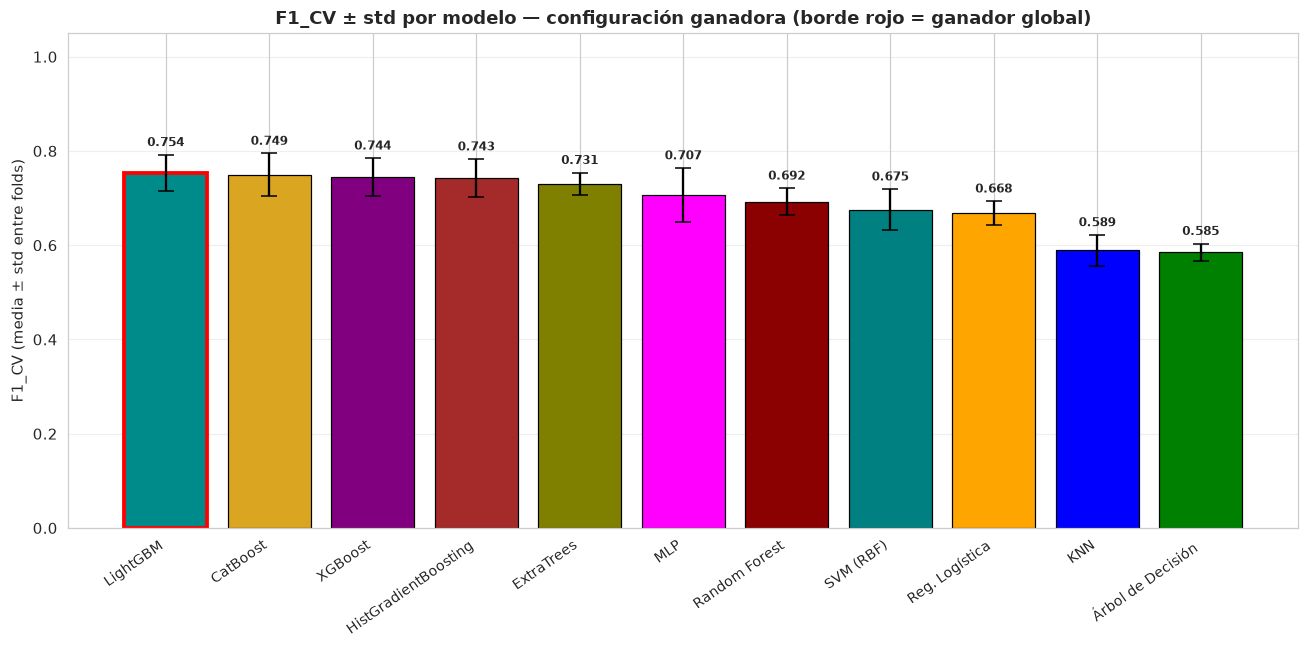

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
orden = tabla_opt.index.tolist()
medias = tabla_opt['F1_CV (mejor)'].values
stds = tabla_opt['± std (mejor)'].values
colores = [MODEL_COLORS[m] for m in orden]
barras = ax.bar(range(len(orden)), medias, yerr=stds, capsize=5,
                color=colores, edgecolor='black', linewidth=0.8,
                error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
# resaltar ganador (mayor F1_CV)
idx_win = int(np.argmax(medias))
barras[idx_win].set_edgecolor('red'); barras[idx_win].set_linewidth(2.5)
for i, (mu, sd) in enumerate(zip(medias, stds)):
    ax.text(i, mu + sd + 0.012, f'{mu:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(orden))); ax.set_xticklabels(orden, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('F1_CV (media ± std entre folds)'); ax.set_ylim(0, 1.05)
ax.set_title('F1_CV ± std por modelo — configuración ganadora (borde rojo = ganador global)',
             fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('outputs_sprint2/optuna_f1_cv_std_barras.png', bbox_inches='tight'); plt.show()

In [21]:
# Ganador global por F1_CV (mejor) — Optuna prevalece si mejora al default
mejor_modelo_ab = tabla_opt['F1_CV (mejor)'].idxmax()
mejor_set_ab = optuna_res[mejor_modelo_ab]['set']
mejor_bal_ab = optuna_res[mejor_modelo_ab]['bal']
Xtr_ganador, Xte_ganador = sets[mejor_set_ab]

f1_def_g = optuna_res[mejor_modelo_ab]['f1_default']
f1_opt_g = optuna_res[mejor_modelo_ab]['f1_optuna']
if f1_opt_g >= f1_def_g:
    config_final, f1_final, params_final = '+ Optuna', f1_opt_g, optuna_res[mejor_modelo_ab]['params']
else:
    config_final, f1_final, params_final = 'Mejor experimento', f1_def_g, {}

print(f'GANADOR GLOBAL: {mejor_modelo_ab} con "{mejor_set_ab}"')
print(f'   Balanceo: {mejor_bal_ab} | Config: {config_final}')
print(f'   F1_CV = {f1_final:.4f}  (default={f1_def_g:.4f}, optuna={f1_opt_g:.4f})')
print(f'   Params: {params_final}')

GANADOR GLOBAL: LightGBM con "E5 +FE+Cluster LOG"
   Balanceo: SMOTETomek | Config: + Optuna
   F1_CV = 0.7540  (default=0.7402, optuna=0.7540)
   Params: {'learning_rate': 0.1287222365527861, 'n_estimators': 167, 'num_leaves': 48, 'min_child_samples': 27}


In [22]:
if config_final == '+ Optuna':
    pipe_final = pipeline_optuna(mejor_modelo_ab, params_final, mejor_bal_ab)
else:
    pipe_final = construir_pipeline(mejor_modelo_ab, mejor_bal_ab)

pipe_final.fit(Xtr_ganador, y_train)
y_pred_ho = pipe_final.predict(Xte_ganador)
y_sco_ho = scores_pos(pipe_final, Xte_ganador)
metr_ho = metricas_holdout(y_test, y_pred_ho, y_sco_ho)

METRICAS = ['F1', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC', 'AUC-PR']
print('Métricas en HOLD-OUT (informativas):')
for m in METRICAS:
    print(f'  {m}: {metr_ho[m]:.4f}')

Métricas en HOLD-OUT (informativas):
  F1: 0.7568
  Accuracy: 0.9368
  Precision: 0.7119
  Recall: 0.8077
  AUC-ROC: 0.9586
  AUC-PR: 0.8164


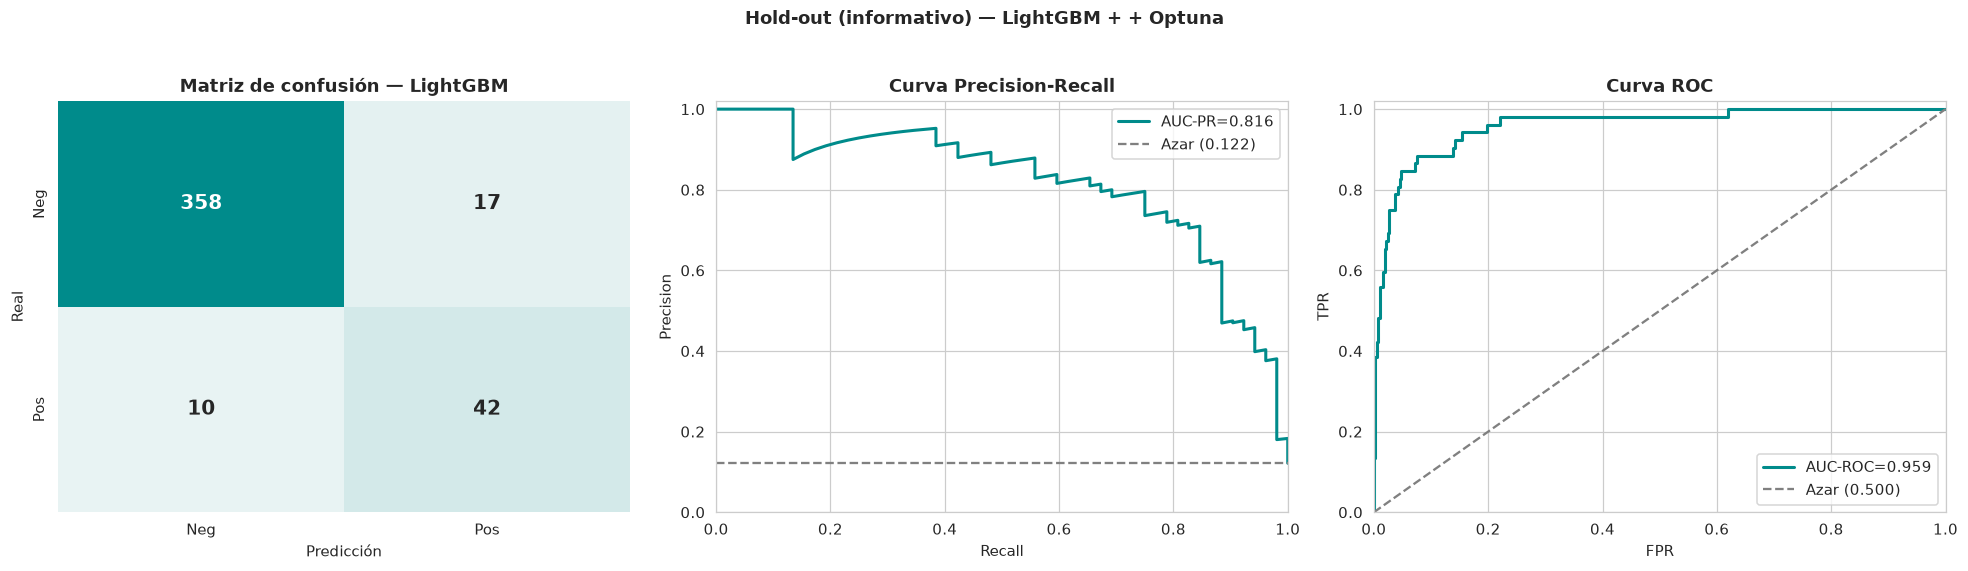

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred_ho)
sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[0],
            cmap=sns.light_palette(MODEL_COLORS[mejor_modelo_ab], as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[0].set_title(f'Matriz de confusión — {mejor_modelo_ab}', fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

p, r, _ = precision_recall_curve(y_test, y_sco_ho)
axes[1].plot(r, p, color=MODEL_COLORS[mejor_modelo_ab], lw=2, label=f'AUC-PR={metr_ho["AUC-PR"]:.3f}')
axes[1].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva Precision-Recall', fontweight='bold'); axes[1].legend()

fpr, tpr, _ = roc_curve(y_test, y_sco_ho)
axes[2].plot(fpr, tpr, color=MODEL_COLORS[mejor_modelo_ab], lw=2, label=f'AUC-ROC={metr_ho["AUC-ROC"]:.3f}')
axes[2].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1.02)
axes[2].set_title('Curva ROC', fontweight='bold'); axes[2].legend(loc='lower right')
plt.suptitle(f'Hold-out (informativo) — {mejor_modelo_ab} + {config_final}', fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig('outputs_sprint2/final_curvas_holdout.png', bbox_inches='tight'); plt.show()

## Resumen

In [24]:
cluster_feats_ganador = [c for c in Xtr_ganador.columns if c.startswith(
    ('kmeans_label_', 'kmeans_dist_', 'gmm_label_', 'gmm_prob_max_', 'dbscan_outlier_'))]
tiene_fe = any(c in Xtr_ganador.columns for c in RATIOS_SEL)

# Inferir espacio de clustering del set ganador
if 'Cluster RAW' in mejor_set_ab:
    cluster_espacio_ganador = 'RAW'
elif 'Cluster LOG' in mejor_set_ab:
    cluster_espacio_ganador = 'LOG'
else:
    cluster_espacio_ganador = None  # E0 o E1 (sin clustering)

resumen2 = {
    'sprint': 2,
    'nombre': 'Feature Engineering (log-ratios no económicos + VIF), clustering y Optuna',
    'protocolo': 'Decisión por F1_CV 5-fold; FE geológico + control VIF; clustering RAW/LOG; hold-out informativo.',
    'mejor_modelo': mejor_modelo_ab,
    'mejor_set': mejor_set_ab,
    'config_final': config_final,
    'metodo_balanceo': mejor_bal_ab,
    'f1_cv_final': round(f1_final, 4),
    'f1_holdout': round(metr_ho['F1'], 4),
    'f1_final': round(f1_final, 4),
    'f1_sprint0': RESUMEN_S1['f1_sprint0'],
    'f1_sprint1': F1_SPRINT1,
    'mejora_vs_sprint1': round(f1_final - F1_SPRINT1, 4),
    'metricas_holdout': {m: round(metr_ho[m], 4) for m in METRICAS},
    'best_params_optuna': params_final,
    'n_trials_optuna': N_TRIALS,
    'optuna_comparativa': {m: {'set': optuna_res[m]['set'], 'balanceo': optuna_res[m]['bal'],
                               'f1_default': round(optuna_res[m]['f1_default'], 4),
                               'std_default': round(optuna_res[m]['std_default'], 4),
                               'f1_optuna': round(optuna_res[m]['f1_optuna'], 4),
                               'std_optuna': round(optuna_res[m]['std_optuna'], 4),
                               'params': optuna_res[m]['params']} for m in MODELOS},
    # --- info para reconstrucción en Sprint 3 ---
    'elementos_economicos': ECONOMICOS,
    'elementos_no_economicos': NO_ECON,
    'umbral_censura': UMBRAL_CENS,
    'features_log_base': ASIM,
    'ratios_seleccionados': RATIOS_SEL,
    'n_ratios_creados': int(N_RATIOS_CREADOS),
    'n_ratios_post_corr': int(N_RATIOS_CORR),
    'n_ratios_post_vif': len(RATIOS_SEL),
    'umbral_corr': UMBRAL_CORR,
    'umbral_vif': UMBRAL_VIF,
    'cluster_espacio_ganador': cluster_espacio_ganador,
    'cluster_info_raw': info_raw,
    'cluster_info_log': info_log,
    'features_clustering': cluster_feats_ganador,
    'set_ganador_tiene_fe': bool(tiene_fe),
    'f1_cv_experimentos': {exp: {m: float(f1_ab.loc[exp, m]) for m in MODELOS} for exp in f1_ab.index},
    'features_set_ganador': list(Xtr_ganador.columns),
    'n_features_base': len(FEATURES_BASE),
    'n_features_final': Xtr_ganador.shape[1],
}
with open('outputs_sprint2/resumen_sprint2.json', 'w') as f:
    json.dump(resumen2, f, indent=2, ensure_ascii=False)

print('════════════════════ RESUMEN SPRINT 2 ════════════════════')
print(f'FE: log-ratios entre {len(NO_ECON)} no económicos → {N_RATIOS_CREADOS} creados '
      f'→ {N_RATIOS_CORR} tras corr → {len(RATIOS_SEL)} tras VIF')
print(f'Clustering (5 features KMeans+GMM+DBSCAN) sobre elementos no económicos en RAW y LOG.')
print(f'\nGANADOR: {mejor_modelo_ab} con "{mejor_set_ab}"')
print(f'   Config: {config_final} | Balanceo: {mejor_bal_ab}')
print(f'   F1_CV       = {f1_final:.4f}   (decisión)')
print(f'   F1 hold-out = {metr_ho["F1"]:.4f}   (informativo)')
print(f'\nEvolución del proyecto (por F1_CV):')
print(f'   Sprint 0 = {RESUMEN_S1["f1_sprint0"]:.4f} (baseline)')
print(f'   Sprint 1 = {F1_SPRINT1:.4f} ({F1_SPRINT1-RESUMEN_S1["f1_sprint0"]:+.4f})')
print(f'   Sprint 2 = {f1_final:.4f} ({f1_final-F1_SPRINT1:+.4f})')
print(f'\nFeatures: {len(FEATURES_BASE)} base → {Xtr_ganador.shape[1]} en set ganador')
print('\nSiguiente (Sprint 3): SHAP selecciona/reduce sobre lo creado aquí; calibración y threshold.')

════════════════════ RESUMEN SPRINT 2 ════════════════════
FE: log-ratios entre 39 no económicos → 741 creados → 555 tras corr → 93 tras VIF
Clustering (5 features KMeans+GMM+DBSCAN) sobre elementos no económicos en RAW y LOG.

GANADOR: LightGBM con "E5 +FE+Cluster LOG"
   Config: + Optuna | Balanceo: SMOTETomek
   F1_CV       = 0.7540   (decisión)
   F1 hold-out = 0.7568   (informativo)

Evolución del proyecto (por F1_CV):
   Sprint 0 = 0.7090 (baseline)
   Sprint 1 = 0.7277 (+0.0187)
   Sprint 2 = 0.7540 (+0.0263)

Features: 46 base → 144 en set ganador

Siguiente (Sprint 3): SHAP selecciona/reduce sobre lo creado aquí; calibración y threshold.
